In [10]:
!pip install kagglehub[pandas-datasets]



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<h1>Treinando o modelo de clusterização Kmeans </h1>

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

file_path = "iris.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "himanshunakrani/iris-dataset",
  file_path
)

print("First 5 records:", df.head())

C:\Users\maria\AppData\Local\Temp\ipykernel_14720\220261672.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:


def aplicar_kmeans(dados, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(dados)
    return kmeans.labels_, kmeans.cluster_centers_




def calcular_inertia(dados, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(dados)
    return kmeans.inertia_


def plotar_clusters(dados, labels, centroids):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(dados.iloc[:, 0], dados.iloc[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
    plt.xlabel(dados.columns[0])
    plt.ylabel(dados.columns[1])
    plt.title('K-Means Clustering')
    plt.legend()
    plt.show()

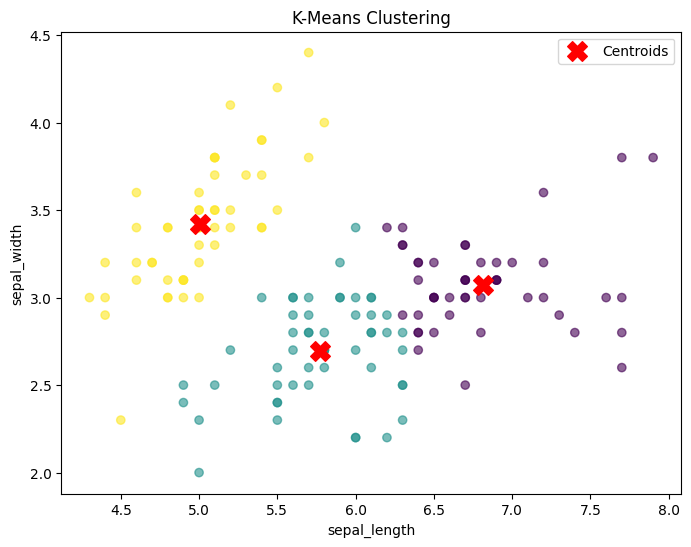

In [13]:
aplicar_kmeans(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']], 3)
calcular_inertia(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']], 3)
plotar_clusters(df[['sepal_length', 'sepal_width']],
                *aplicar_kmeans(df[['sepal_length', 'sepal_width']], 3)[0:2])

In [14]:
def metodo_elbow():
    inertias = []
    k_values = range(1, 11)
    for k in k_values:
        inertia = calcular_inertia(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']], k)
        inertias.append(inertia)
    
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, inertias, marker='o')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Inércia')
    plt.title('Método Elbow para Determinar o Número Ótimo de Clusters')
    plt.xticks(k_values)
    plt.show()

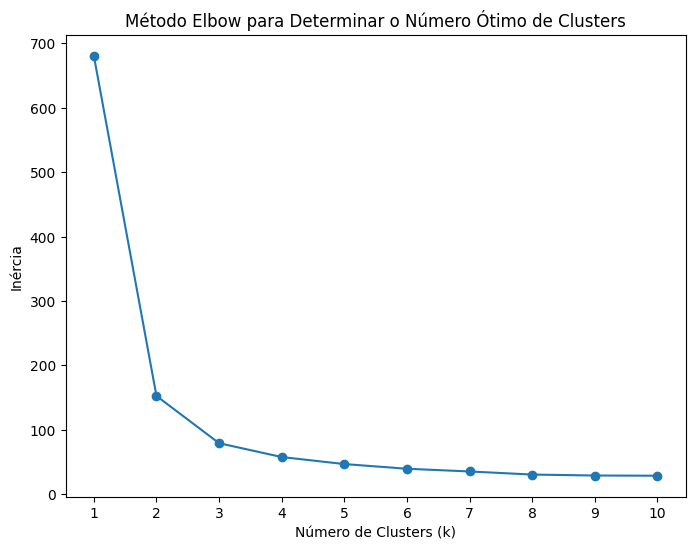

In [15]:
metodo_elbow()

In [16]:
def silhouette_metrica(dados, labels):
    from sklearn.metrics import silhouette_score
    score = silhouette_score(dados, labels)
    print(f'Silhouette Score: {score:.4f}')
    return score

silhouette_metrica(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']],
    aplicar_kmeans(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']], 3)[0])

Silhouette Score: 0.5510


0.5509643746707443